# Preprocesamiento de Datos
## 1. Carga de librerías y datos

In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Configuraciones de visualización
sns.set_theme(style="whitegrid")

# Cargar los datos desde raw
filepath = '../data/raw/db_orig.csv'
df = pd.read_csv(filepath)
df.head()

,Description,Date,Amount,Area,Type
0,Entretenimiento,28/02/2026,"10,00€",Leisure,Expenses
1,Nómina mensual,27/02/2026,"629,58€",Salary,Income
2,Gasto vacaciones,25/02/2026,"51,00€","Leisure, Vacations",Expenses
3,Pequeño ocio,22/02/2026,"2,80€",Leisure,Expenses
4,Compra alimentación,21/02/2026,"24,80€",Food,Expenses


## 2. Inspección inicial y formato de columnas
Dado que los datos no tienen valores nulos, pasamos a procesar formatos de fechas y números.

In [33]:
# Convertimos 'Date' a datetime
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')

In [34]:
# 'Amount' viene como string con coma, € y punto. Lo pasamos a float
if df['Amount'].dtype == 'str':
    df['Amount'] = df['Amount'].str.replace('€', '')
    df['Amount'] = df['Amount'].str.replace('.', '')
    df['Amount'] = df['Amount'].str.replace(',', '.').astype(float)

In [35]:
# Convertir los gastos ('Expenses') en valores negativos
if 'Type' in df.columns:
    df.loc[df['Type'] == 'Expenses', 'Amount'] = -df.loc[df['Type'] == 'Expenses', 'Amount'].abs()

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 885 entries, 0 to 884
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Description  885 non-null    str           
 1   Date         885 non-null    datetime64[us]
 2   Amount       885 non-null    float64       
 3   Area         885 non-null    str           
 4   Type         885 non-null    str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 34.7 KB


## 3. Eliminación de Columnas Irrelevantes
Para la predicción de gastos no nos hace falta saber los datos de la columna `Description` ni `Type` por lo que las eliminamos.

In [36]:
# Eliminar columnas irrelevantes en el DataFrame original
cols_to_drop = ['Description', 'Type']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
df.head()

,Date,Amount,Area
0,2026-02-28,-10.00,Leisure
1,2026-02-27,629.58,Salary
2,2026-02-25,-51.00,"Leisure, Vacations"
3,2026-02-22,-2.80,Leisure
4,2026-02-21,-24.80,Food


## 4. Conversión de variables categóricas
Convertimos `Area` en variable numérica para poder ver la correlación y usar modelos de ML.

In [37]:
# Separamos las etiquetas de áreas que haya en la misma fila en filas diferentes y les damos un valor numérico

label_encoder = LabelEncoder()
df['Area'] = label_encoder.fit_transform(df['Area'])

# Mostramos el DataFrame
print(f"Categorías: {dict(enumerate(label_encoder.classes_))}\n")
print(f"Cabecera del df:\n{df.head()}")

Categorías: {0: 'Deposit', 1: 'Food', 2: 'Food, Vacations', 3: 'Investment', 4: 'Invoice', 5: 'Invoice, Vacations', 6: 'Leisure', 7: 'Leisure, Vacations', 8: 'Salary'}

Cabecera del df:
        Date  Amount  Area
0 2026-02-28  -10.00     6
1 2026-02-27  629.58     8
2 2026-02-25  -51.00     7
3 2026-02-22   -2.80     6
4 2026-02-21  -24.80     1


## 5. Matriz de Correlación
Visualizamos cómo interactúan las variables ahora que todas son numéricas.

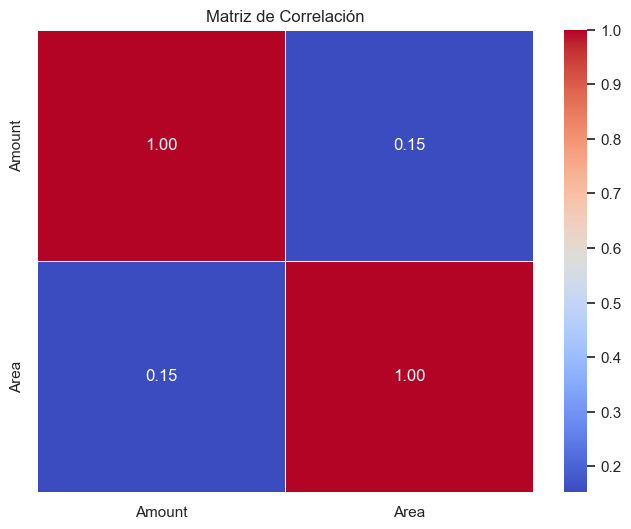

In [38]:
plt.figure(figsize=(8, 6))

# Excluimos la columna de fecha para la correlación numérica directa
if 'Date' in df.columns:
    df_num = df.drop(columns=['Date'])
else:
    df_num = df.copy()

corr_matrix = df_num.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación')
plt.show()

## 6. División en Train, Validation y Test
Dividiremos en: 70% Train, 15% Validation, 15% Test.

In [39]:
# Al ser datos temporales, ordenamos por fecha y evitamos mezclar aleatoriamente (shuffle=False)
df = df.sort_values(by='Date').reset_index(drop=True)

df.head()

,Date,Amount,Area
0,2021-09-01,-1.50,6
1,2021-09-07,-64.35,4
2,2021-09-07,613.62,8
3,2021-09-11,-3.00,6
4,2021-09-12,-10.75,6


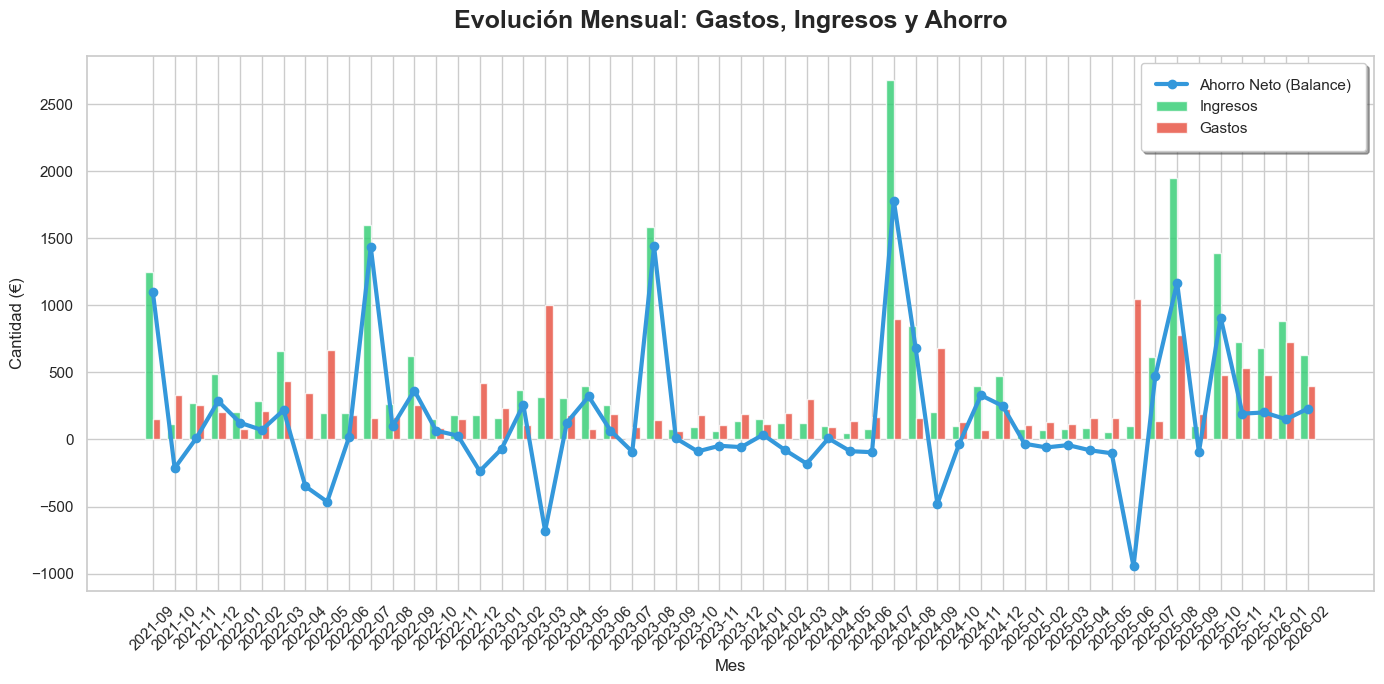

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar los datos
file_path = '../data/raw/db_orig.csv'
df = pd.read_csv(file_path)

# 2. Limpieza de datos (Preprocesamiento)
# Convertir 'Amount' de cadena (ej: "10,00€") a float
df['Amount'] = df['Amount'].str.replace('€', '', regex=False)
df['Amount'] = df['Amount'].str.replace('.', '', regex=False)  # Quitar separador de miles
df['Amount'] = df['Amount'].str.replace(',', '.', regex=False) # Cambiar coma decimal por punto
df['Amount'] = df['Amount'].astype(float)

# Convertir 'Date' a datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Crear columna de Mes para agrupar (Periodo YYYY-MM)
df['Month'] = df['Date'].dt.to_period('M')

# 3. Agrupar por Mes y Tipo
monthly_data = df.groupby(['Month', 'Type'])['Amount'].sum().unstack(fill_value=0)

# Asegurar que existan ambas columnas si no hay datos de alguna
if 'Expenses' not in monthly_data.columns: monthly_data['Expenses'] = 0
if 'Income' not in monthly_data.columns: monthly_data['Income'] = 0

# Calcular el Ahorro (Ingresos - Gastos)
monthly_data['Savings'] = monthly_data['Income'] - monthly_data['Expenses']

# Convertir el índice de periodos a strings para mejor visualización en la gráfica
plot_data = monthly_data.copy()
plot_data.index = plot_data.index.astype(str)

# 4. Visualización Premium
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# Dibujar Barras de Ingresos y Gastos
x = range(len(plot_data))
width = 0.35

plt.bar([i - width/2 for i in x], plot_data['Income'], width, label='Ingresos', color='#2ecc71', alpha=0.8)
plt.bar([i + width/2 for i in x], plot_data['Expenses'], width, label='Gastos', color='#e74c3c', alpha=0.8)

# Dibujar Línea de Ahorro
plt.plot(x, plot_data['Savings'], marker='o', color='#3498db', linewidth=3, label='Ahorro Neto (Balance)')

# Configuración estética
plt.title('Evolución Mensual: Gastos, Ingresos y Ahorro', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Cantidad (€)', fontsize=12)
plt.xticks(x, plot_data.index, rotation=45)
plt.legend(frameon=True, shadow=True, borderpad=1)
plt.tight_layout()

plt.show()


In [ ]:
# Mostramos una gráfica del gasto-ahorro mensual de la base de datos

In [ ]:


train_df, temp_df = train_test_split(df, test_size=0.30, shuffle=False)
val_df, test_df = train_test_split(temp_df, test_size=0.50, shuffle=False)

print(f"Total datos: {len(df)}")
print(f"Train: {len(train_df)}")
print(f"Validation: {len(val_df)}")
print(f"Test: {len(test_df)}")

Total datos: 2385
Train: 1669
Validation: 358
Test: 358


In [ ]:
import os

os.makedirs('../data/processed', exist_ok=True)

# Guardamos los conjuntos procesados
train_df.to_csv('../data/processed/train.csv', index=False)
val_df.to_csv('../data/processed/val.csv', index=False)
test_df.to_csv('../data/processed/test.csv', index=False)
print("Datos guardados exitosamente en la carpeta 'data/processed/'")


Datos guardados exitosamente en la carpeta 'data/processed/'


C:\Users\diego\AppData\Local\Temp\ipykernel_5932\2751839683.py:17: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)


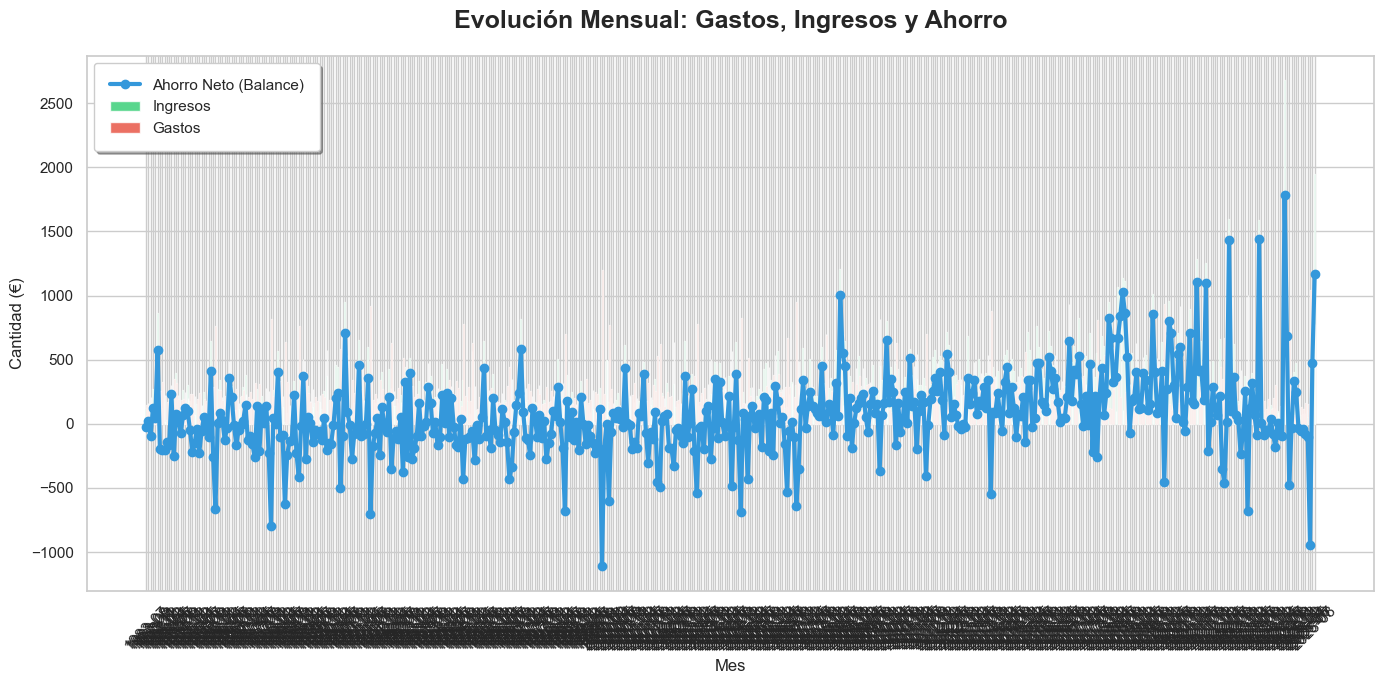

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar los datos
file_path = '../data/raw/db_trunc_until_202508_extended_v2.csv'
df = pd.read_csv(file_path)

# 2. Limpieza de datos (Preprocesamiento)
# Convertir 'Amount' de cadena (ej: "10,00€") a float
# df['Amount'] = df['Amount'].str.replace('€', '', regex=False)
# df['Amount'] = df['Amount'].str.replace('.', '', regex=False)  # Quitar separador de miles
# df['Amount'] = df['Amount'].str.replace(',', '.', regex=False) # Cambiar coma decimal por punto
# df['Amount'] = df['Amount'].astype(float)

# Convertir 'Date' a datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Crear columna de Mes para agrupar (Periodo YYYY-MM)
df['Month'] = df['Date'].dt.to_period('M')

# 3. Agrupar por Mes y Tipo
monthly_data = df.groupby(['Month', 'Type'])['Amount'].sum().unstack(fill_value=0)

# Asegurar que existan ambas columnas si no hay datos de alguna
if 'Expenses' not in monthly_data.columns: monthly_data['Expenses'] = 0
if 'Income' not in monthly_data.columns: monthly_data['Income'] = 0

# Calcular el Ahorro (Ingresos - Gastos)
monthly_data['Savings'] = monthly_data['Income'] - monthly_data['Expenses']

# Convertir el índice de periodos a strings para mejor visualización en la gráfica
plot_data = monthly_data.copy()
plot_data.index = plot_data.index.astype(str)

# 4. Visualización Premium
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# Dibujar Barras de Ingresos y Gastos
x = range(len(plot_data))
width = 0.35

plt.bar([i - width/2 for i in x], plot_data['Income'], width, label='Ingresos', color='#2ecc71', alpha=0.8)
plt.bar([i + width/2 for i in x], plot_data['Expenses'], width, label='Gastos', color='#e74c3c', alpha=0.8)

# Dibujar Línea de Ahorro
plt.plot(x, plot_data['Savings'], marker='o', color='#3498db', linewidth=3, label='Ahorro Neto (Balance)')

# Configuración estética
plt.title('Evolución Mensual: Gastos, Ingresos y Ahorro', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Cantidad (€)', fontsize=12)
plt.xticks(x, plot_data.index, rotation=45)
plt.legend(frameon=True, shadow=True, borderpad=1)
plt.tight_layout()

plt.show()
